# EDA: Horno de Sostenimiento | Equipo 2 · RONAL GROUP
**Curso:** MA2008B — Análisis numérico para la optimización no-lineal  
**Objetivo:** Entender la dinámica térmica del horno para justificar una arquitectura de Deep Learning.


In [1]:
# librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
COLORS = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#3B1F2B',
          '#44BBA4','#E94F37','#393E41','#F5A623','#7B2D8B']


## 1. Carga del Dataset y Verificación de Timestamps


In [ ]:
df = pd.read_csv('dataset_horno_sostenimiento1.csv')

# parsear timestamp real y usarlo como índice
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df.index.freq = 'min'

print(f"Rango temporal : {df.index.min()}  →  {df.index.max()}")
print(f"Forma          : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Frecuencia     : 1 minuto  (esperado: 20,160 muestras = 14 días)")


Rango temporal : 2026-03-01 00:00:00  →  2026-03-14 23:59:00
Forma          : 20,160 filas × 11 columnas
Frecuencia     : 1 minuto  (esperado: 20,160 muestras = 14 días)


## 2. Datos Faltantes


Variables con datos faltantes:
                    Nulos  % del total
sensor_temp_main      548         2.72
sensor_temp_backup    543         2.69


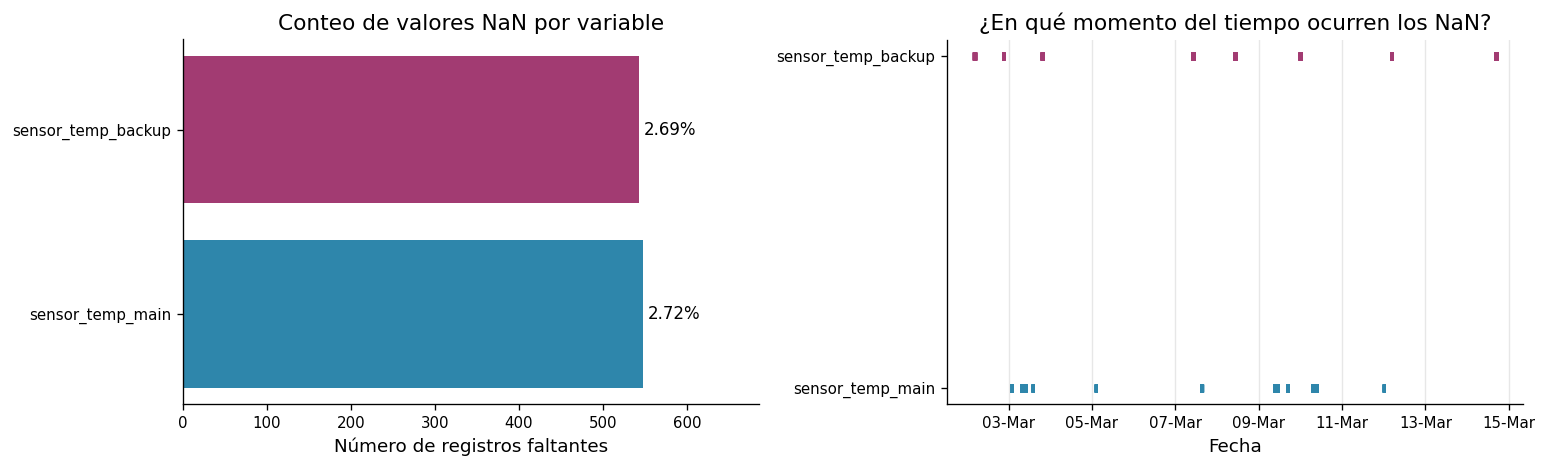

In [ ]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0]
print("Variables con datos faltantes:")
print(nulos_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# panel izquierdo: barra de conteo
ax = axes[0]
bars = ax.barh(nulos_df.index, nulos_df['Nulos'], color=['#2E86AB','#A23B72'])
ax.set_xlabel('Número de registros faltantes')
ax.set_title('Conteo de valores NaN por variable')
for bar, pct in zip(bars, nulos_df['% del total']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)
ax.set_xlim(0, nulos_df['Nulos'].max() * 1.25)

# panel derecho: línea de tiempo mostrando dónde ocurren
ax2 = axes[1]
for i, col in enumerate(nulos_df.index):
    nan_idx = df[col].isna()
    ax2.scatter(df.index[nan_idx], [i]*nan_idx.sum(),
                marker='|', s=20, alpha=0.6, color=COLORS[i], label=col)
ax2.set_yticks(range(len(nulos_df)))
ax2.set_yticklabels(nulos_df.index)
ax2.set_title('¿En qué momento del tiempo ocurren los NaN?')
ax2.set_xlabel('Fecha')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_missing.png', bbox_inches='tight')
plt.show()


## 3. Distribuciones de Variables

Se muestran histogramas con curva de densidad agrupados por rol físico.  
Esto permite ver si las variables tienen comportamiento normal, bimodal o con colas largas.


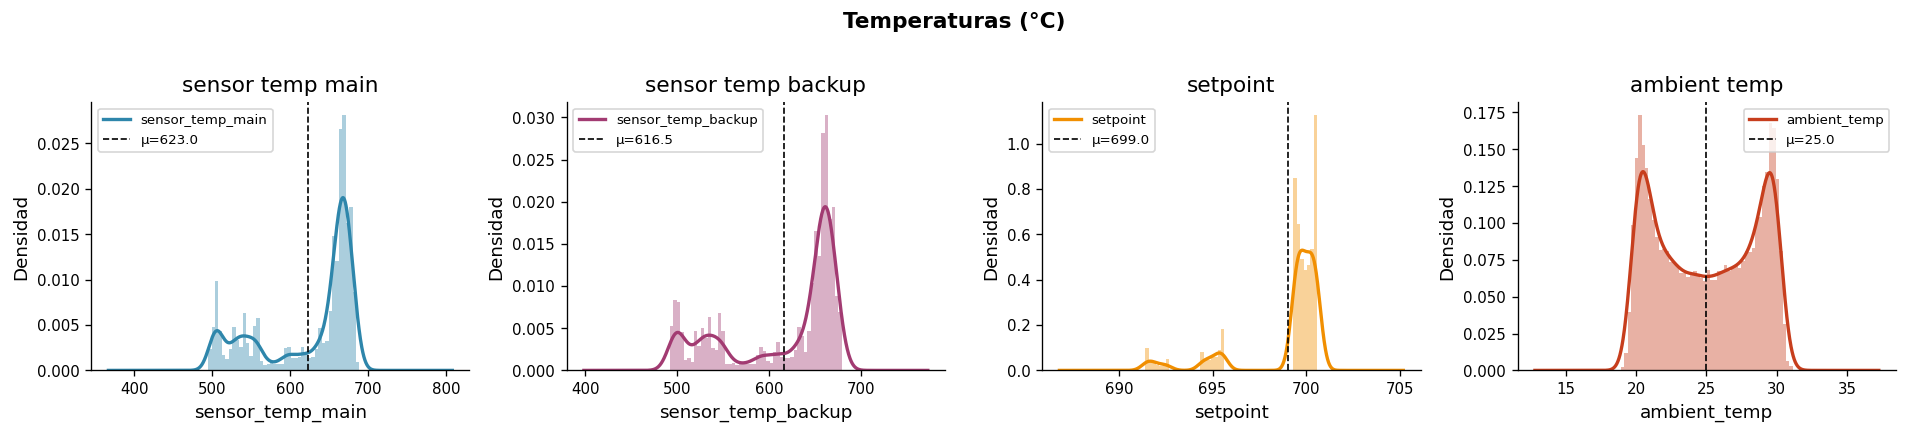

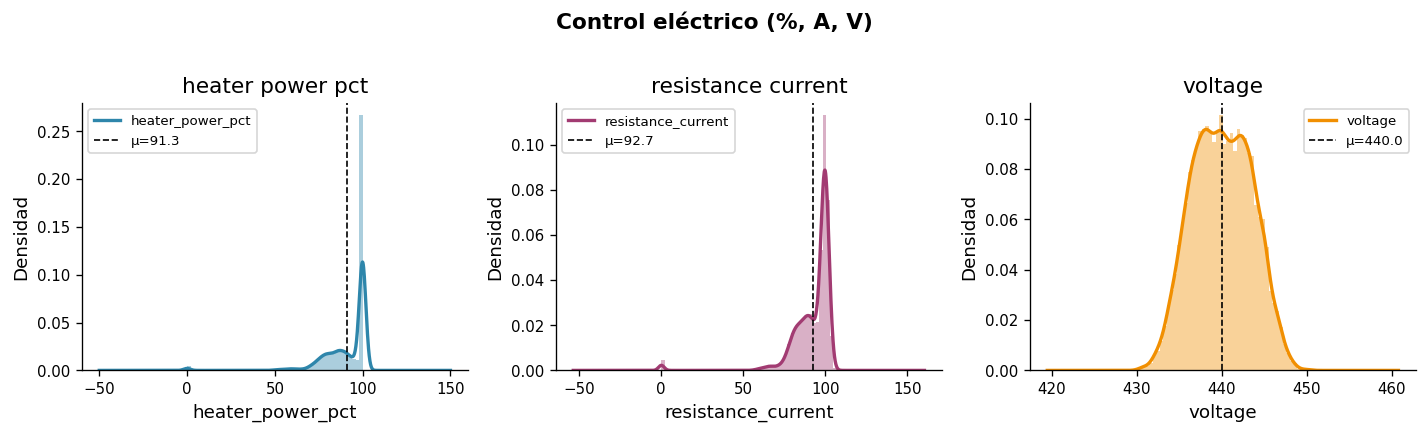

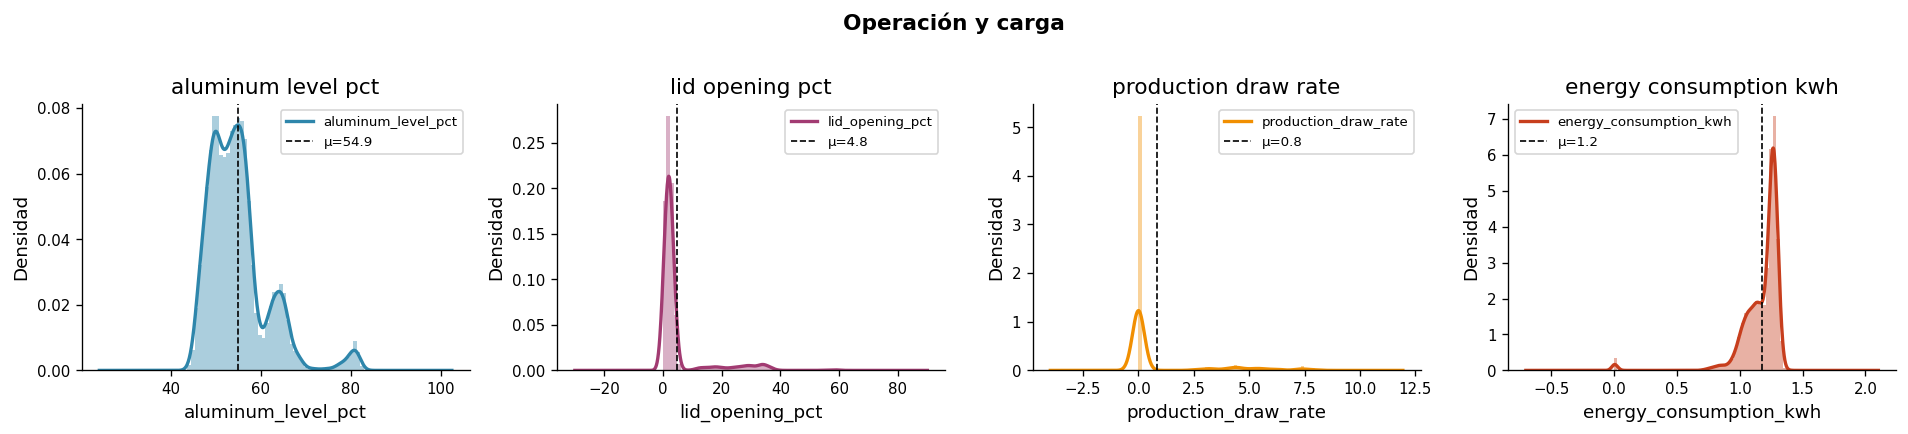

In [ ]:
grupos = {
    'Temperaturas (°C)':
        ['sensor_temp_main','sensor_temp_backup','setpoint','ambient_temp'],
    'Control eléctrico (%, A, V)':
        ['heater_power_pct','resistance_current','voltage'],
    'Operación y carga':
        ['aluminum_level_pct','lid_opening_pct','production_draw_rate','energy_consumption_kwh'],
}

for titulo, vars_grupo in grupos.items():
    n = len(vars_grupo)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3.5))
    if n == 1: axes = [axes]
    fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.02)
    for ax, col, color in zip(axes, vars_grupo, COLORS):
        data = df[col].dropna()
        ax.hist(data, bins=50, density=True, alpha=0.4, color=color)
        data.plot.kde(ax=ax, color=color, linewidth=2)
        ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'μ={data.mean():.1f}')
        ax.set_title(col.replace('_',' '))
        ax.set_xlabel(col)
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fig_dist_{titulo[:10].replace(" ","_")}.png', bbox_inches='tight')
    plt.show()


## 4. Limpieza de Datos

1. **Imputación espejo**.
2. **Interpolación lineal**


In [ ]:
df_clean = df.copy()

# imputación espejo
df_clean['sensor_temp_main'] = df_clean['sensor_temp_main'].fillna(df_clean['sensor_temp_backup'])
df_clean['sensor_temp_backup'] = df_clean['sensor_temp_backup'].fillna(df_clean['sensor_temp_main'])

# interpolación lineal para datos faltantes restantes
for col in ['sensor_temp_main','sensor_temp_backup']:
    remanentes = df_clean[col].isna().sum()
    if remanentes > 0:
        print(f"→ Interpolando {remanentes} remanentes en {col}")
        df_clean[col] = df_clean[col].interpolate(method='time')

nulos_post = df_clean.isnull().sum().sum()
print(f"\nValores NaN restantes: {nulos_post}")


✅ Limpieza completada. Valores NaN restantes: 0
   Filas totales conservadas: 20,160 (sin eliminar ninguna fila)


## 5. Dinámica Temporal (14 Días)

Se muestra la evolución de las variables clave a lo largo del periodo completo.


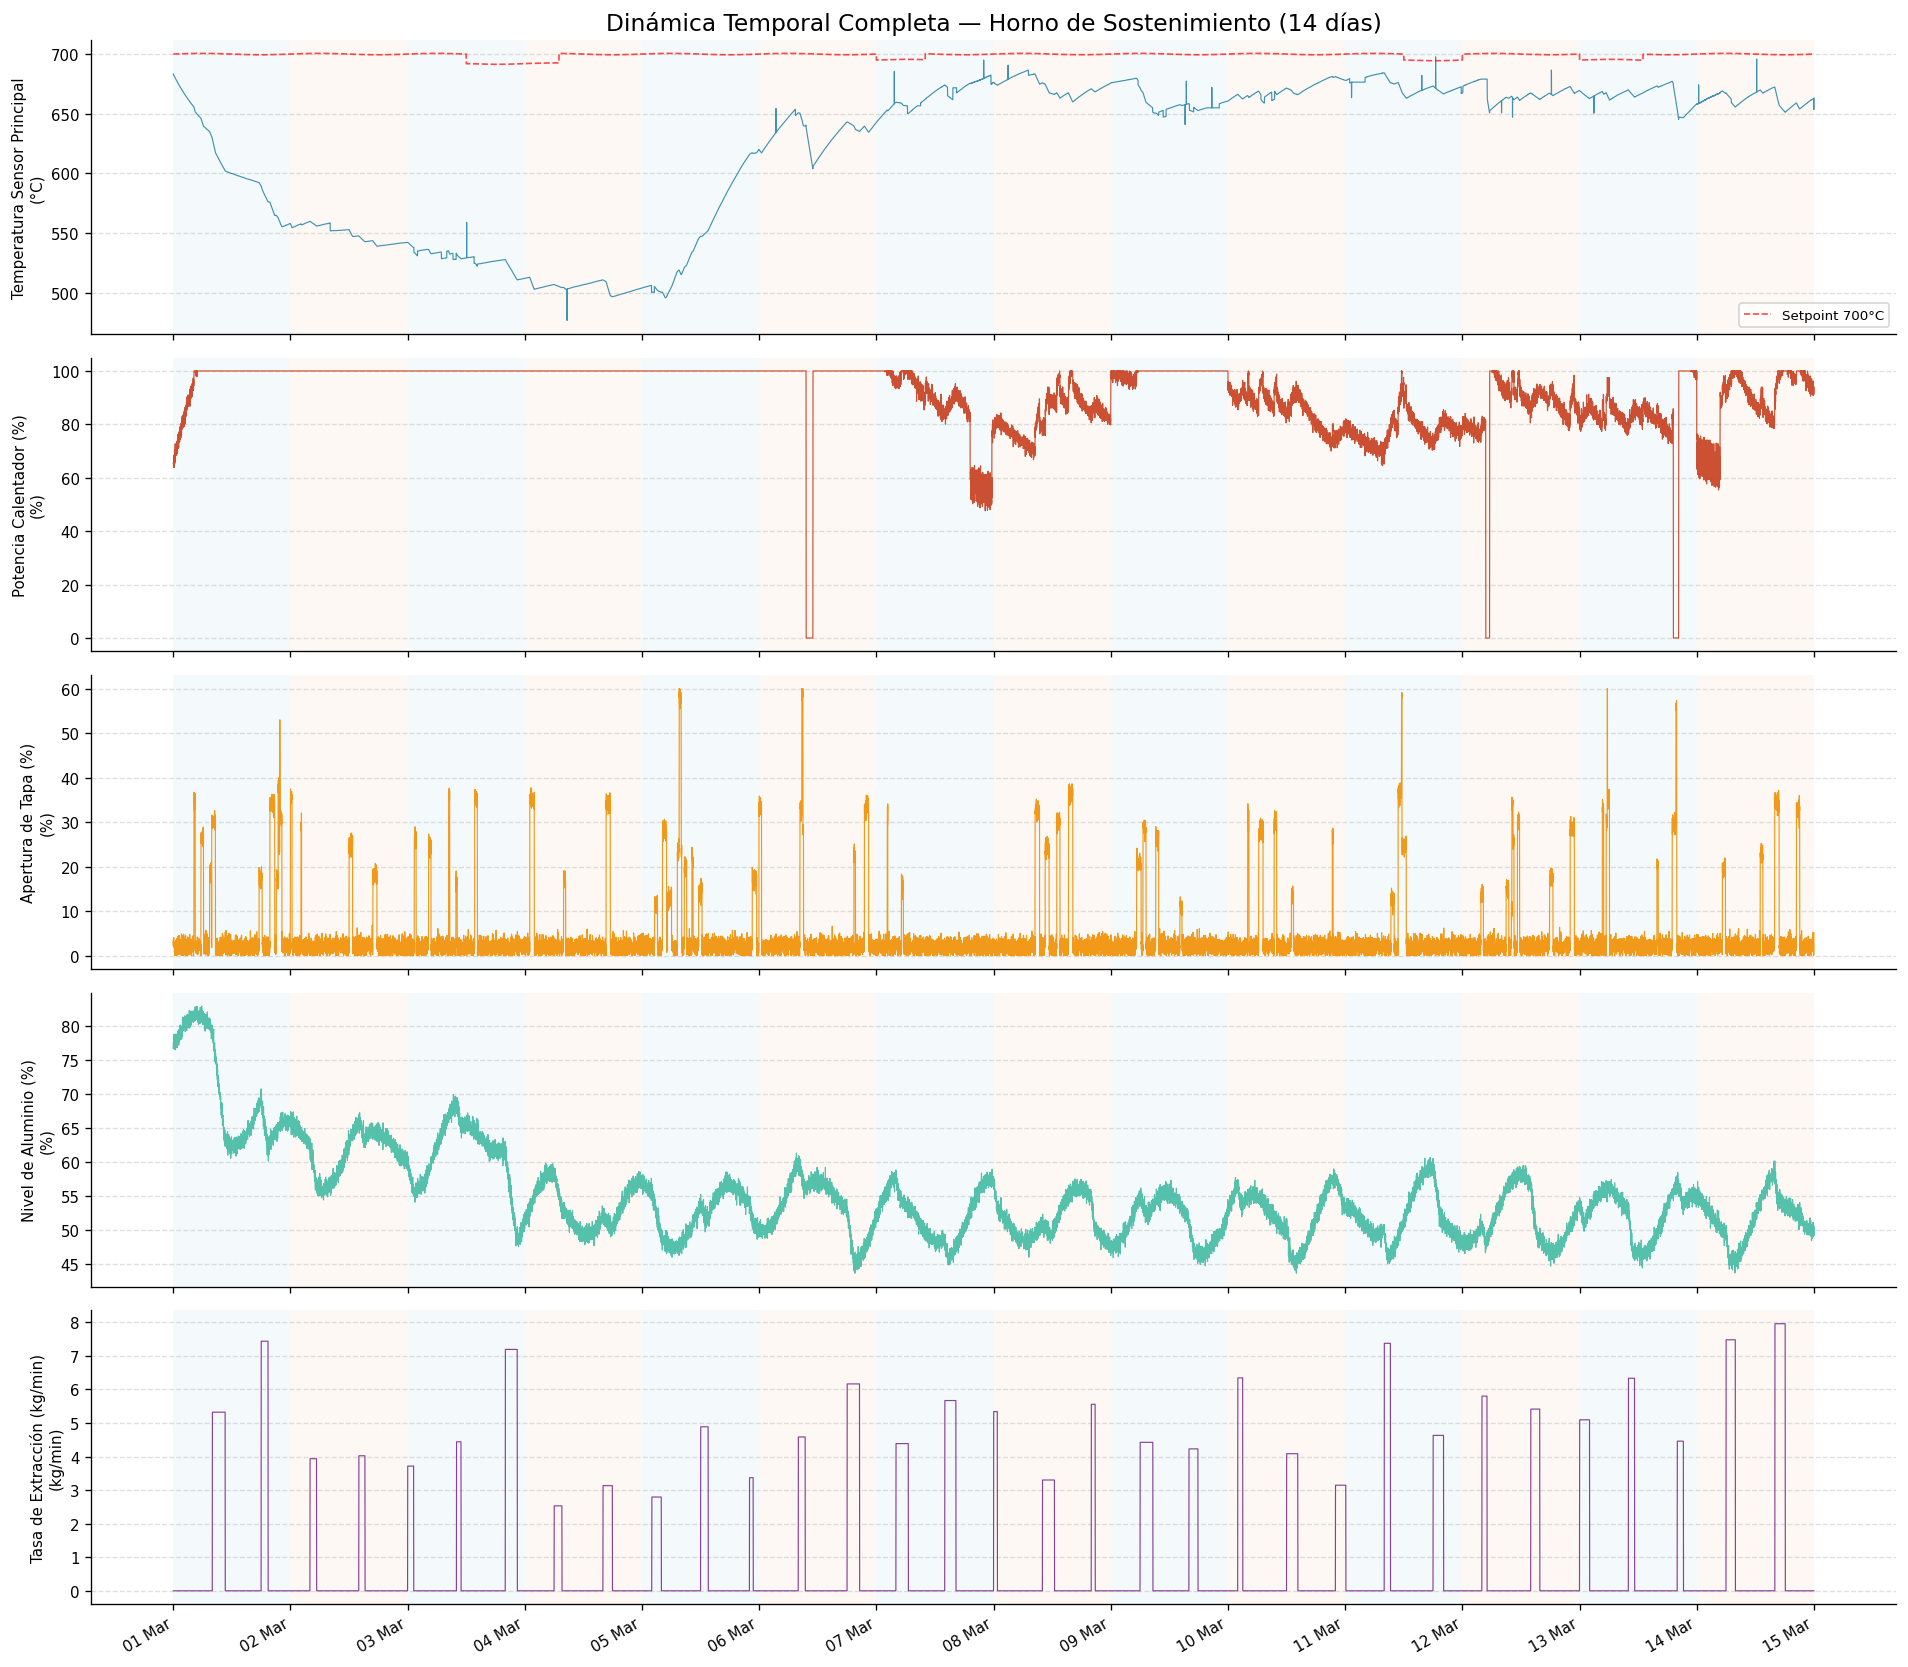

In [ ]:
# paleta de colores alternados para los 14 días
day_colors = ['#EBF5FB','#FDF2E9'] * 7

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

paneles = [
    ('sensor_temp_main',      '°C',  '#2E86AB', 'Temperatura Sensor Principal'),
    ('heater_power_pct',      '%',   '#C73E1D', 'Potencia Calentador (%)'),
    ('lid_opening_pct',       '%',   '#F18F01', 'Apertura de Tapa (%)'),
    ('aluminum_level_pct',    '%',   '#44BBA4', 'Nivel de Aluminio (%)'),
    ('production_draw_rate',  'kg/min','#7B2D8B','Tasa de Extracción (kg/min)'),
]

days = pd.date_range(df_clean.index.min().normalize(), periods=15, freq='D')

for ax, (col, unit, color, label) in zip(axes, paneles):
    for i, (d0, d1) in enumerate(zip(days[:-1], days[1:])):
        ax.axvspan(d0, d1, facecolor=day_colors[i % 2], alpha=0.5, linewidth=0)
    ax.plot(df_clean.index, df_clean[col], color=color, linewidth=0.7, alpha=0.9)
    ax.set_ylabel(f'{label}\n({unit})', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    if col == 'sensor_temp_main':
        ax.plot(df_clean.index, df_clean['setpoint'], color='red',
                linestyle='--', linewidth=1, alpha=0.7, label='Setpoint 700°C')
        ax.legend(fontsize=8, loc='lower right')

axes[0].set_title('Dinámica Temporal Completa — Horno de Sostenimiento (14 días)', fontsize=14)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_temporal_14dias.png', bbox_inches='tight')
plt.show()


## 6. Matriz de Correlación

Correlación de Pearson.

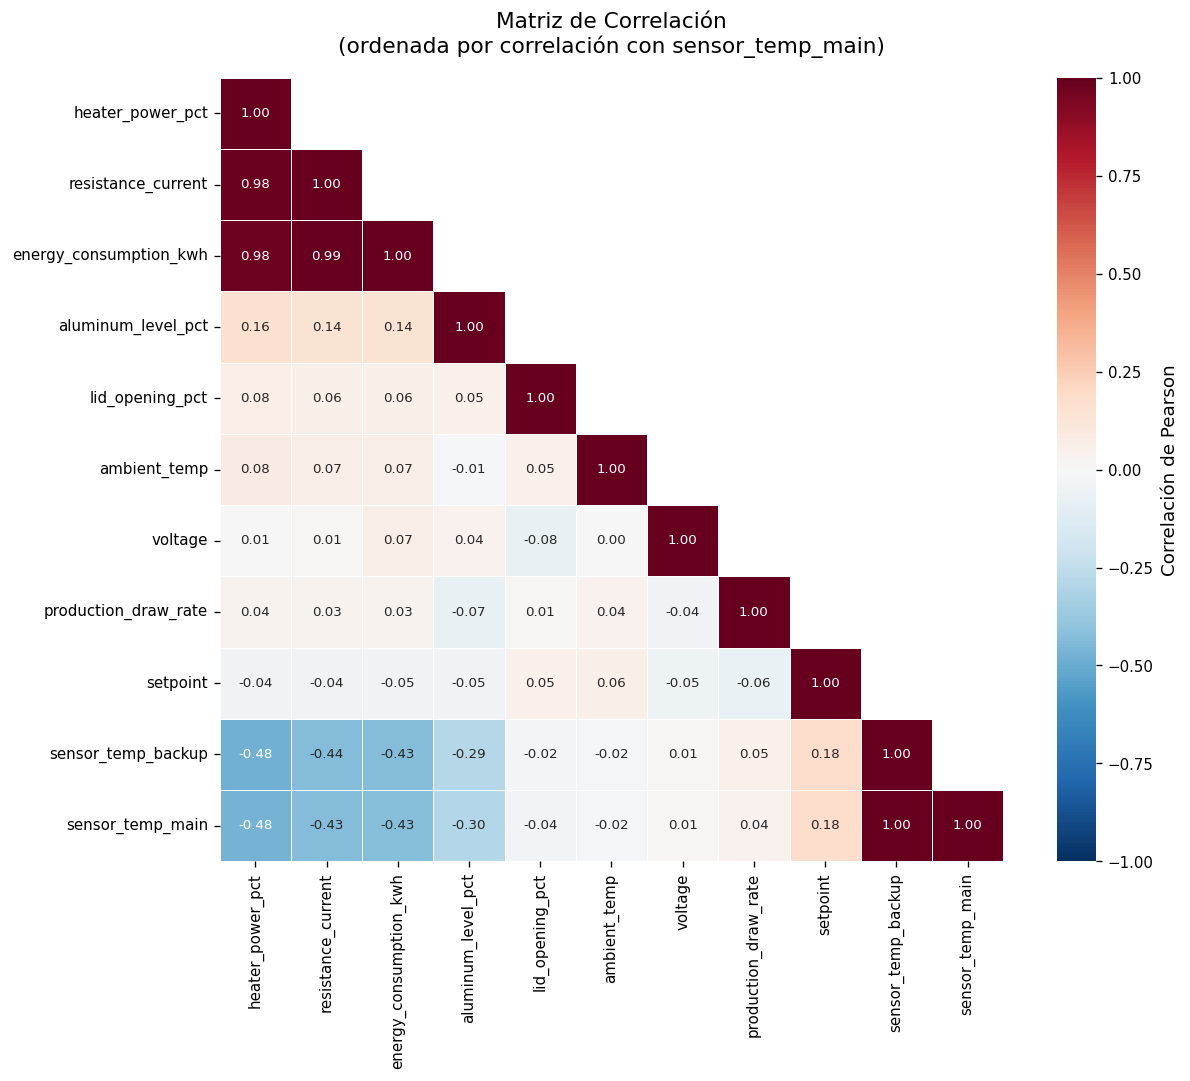


📊 Correlación de cada variable con sensor_temp_main (objetivo):
  heater_power_pct               -0.475  █████████
  resistance_current             -0.430  ████████
  energy_consumption_kwh         -0.427  ████████
  aluminum_level_pct             -0.296  █████
  lid_opening_pct                -0.036  
  ambient_temp                   -0.023  
  voltage                        +0.014  
  production_draw_rate           +0.039  
  setpoint                       +0.184  ███
  sensor_temp_backup             +0.999  ███████████████████


In [ ]:
corr = df_clean.corr(method='pearson')

orden = corr['sensor_temp_main'].sort_values().index.tolist()
corr_ordenada = corr.loc[orden, orden]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_ordenada, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_ordenada, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Correlación de Pearson'}
)
ax.set_title('Matriz de Correlación\n(ordenada por correlación con sensor_temp_main)', pad=15)
plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()


## 7. Análisis de Retardos (Cross-Correlation)


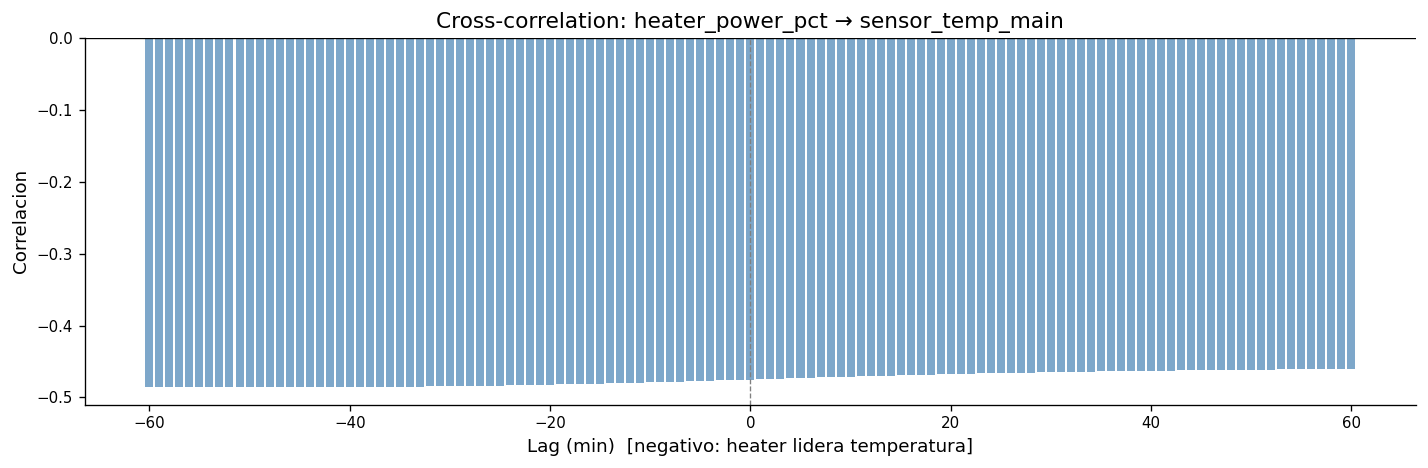

Lag de maxima correlacion (abs): -57 min


In [ ]:
# correlacion de y(t) con x(t-lag) para cada lag
def cross_corr(y, x, max_lags=60):
    y_clean = y.dropna()
    x_clean = x.dropna()
    idx     = y_clean.index.intersection(x_clean.index)
    y_a     = (y_clean[idx] - y_clean[idx].mean()) / y_clean[idx].std()
    x_a     = (x_clean[idx] - x_clean[idx].mean()) / x_clean[idx].std()
    lags    = range(-max_lags, max_lags + 1)
    corrs   = [y_a.corr(x_a.shift(lag)) for lag in lags]
    return list(lags), corrs


lags, corrs = cross_corr(
    df_clean["sensor_temp_main"],
    df_clean["heater_power_pct"],
    max_lags=60,
)

fig_cc, ax = plt.subplots(figsize=(12, 4))
ax.bar(lags, corrs, width=0.8, color="steelblue", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="gray",  linewidth=0.8, linestyle="--")
ax.set_title("Cross-correlation: heater_power_pct → sensor_temp_main")
ax.set_xlabel("Lag (min)  [negativo: heater lidera temperatura]")
ax.set_ylabel("Correlacion")
plt.tight_layout()
plt.savefig("fig_crosscorr.png", bbox_inches="tight", dpi=120)
plt.show()

peak_lag = lags[corrs.index(max(corrs, key=abs))]
print(f"Lag de maxima correlacion (abs): {peak_lag} min")

## 8. Autocorrelación (ACF) y autocorrelación parcial (PACF)

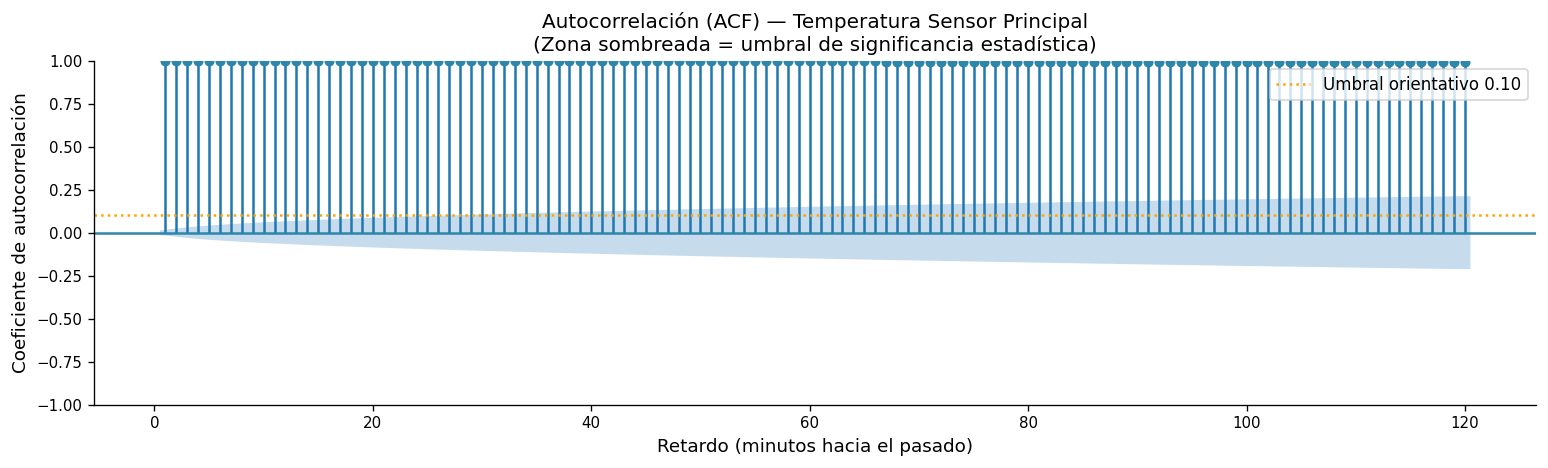

  ACF en lag= 10 min: 0.9994
  ACF en lag= 30 min: 0.9980
  ACF en lag= 60 min: 0.9954
  ACF en lag= 90 min: 0.9924
  ACF en lag=120 min: 0.9892

⚠️  La autocorrelación es extremadamente alta incluso a 2 horas hacia atrás (lag=120).
→ El horno es un sistema de alta inercia térmica: la temperatura actual
  depende FUERTEMENTE de su historia reciente.
→ Esto implica que la ventana de tiempo del modelo debe ser generosa
  (al menos 30–60 min de historia) para capturar la dinámica completa.


In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))

plot_acf(df_clean['sensor_temp_main'], lags=120, ax=ax, color='#2E86AB',
         alpha=0.05, zero=False)

ax.set_title('Autocorrelación (ACF) — Temperatura Sensor Principal\n'
             '(Zona sombreada = umbral de significancia estadística)', fontsize=12)
ax.set_xlabel('Retardo (minutos hacia el pasado)')
ax.set_ylabel('Coeficiente de autocorrelación')
ax.axhline(0.1, color='orange', linestyle=':', linewidth=1.5, label='Umbral orientativo 0.10')
ax.legend()
plt.tight_layout()
plt.savefig('fig_acf.png', bbox_inches='tight')
plt.show()

# Encontrar el primer lag donde ACF cae por debajo de 0.5
from statsmodels.tsa.stattools import acf
acf_vals = acf(df_clean['sensor_temp_main'], nlags=120, fft=True)
# Reportar ACF en lags clave
for lag in [10, 30, 60, 90, 120]:
    print(f"  ACF en lag={lag:3d} min: {acf_vals[lag]:.4f}")

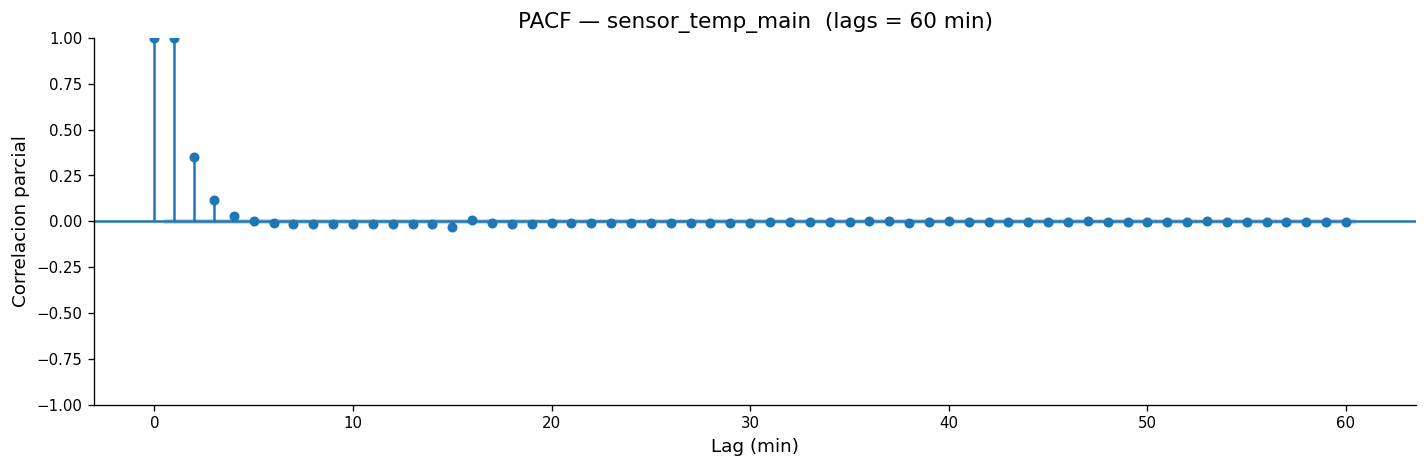

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

fig_pacf, ax = plt.subplots(figsize=(12, 4))
plot_pacf(
    df_clean["sensor_temp_main"].dropna(),
    lags=60,
    method="ywm",
    ax=ax,
    title="PACF — sensor_temp_main  (lags = 60 min)",
)
ax.set_xlabel("Lag (min)")
ax.set_ylabel("Correlacion parcial")
plt.tight_layout()
plt.savefig("fig_pacf.png", bbox_inches="tight", dpi=120)
plt.show()

## 9. Regímenes de Operación


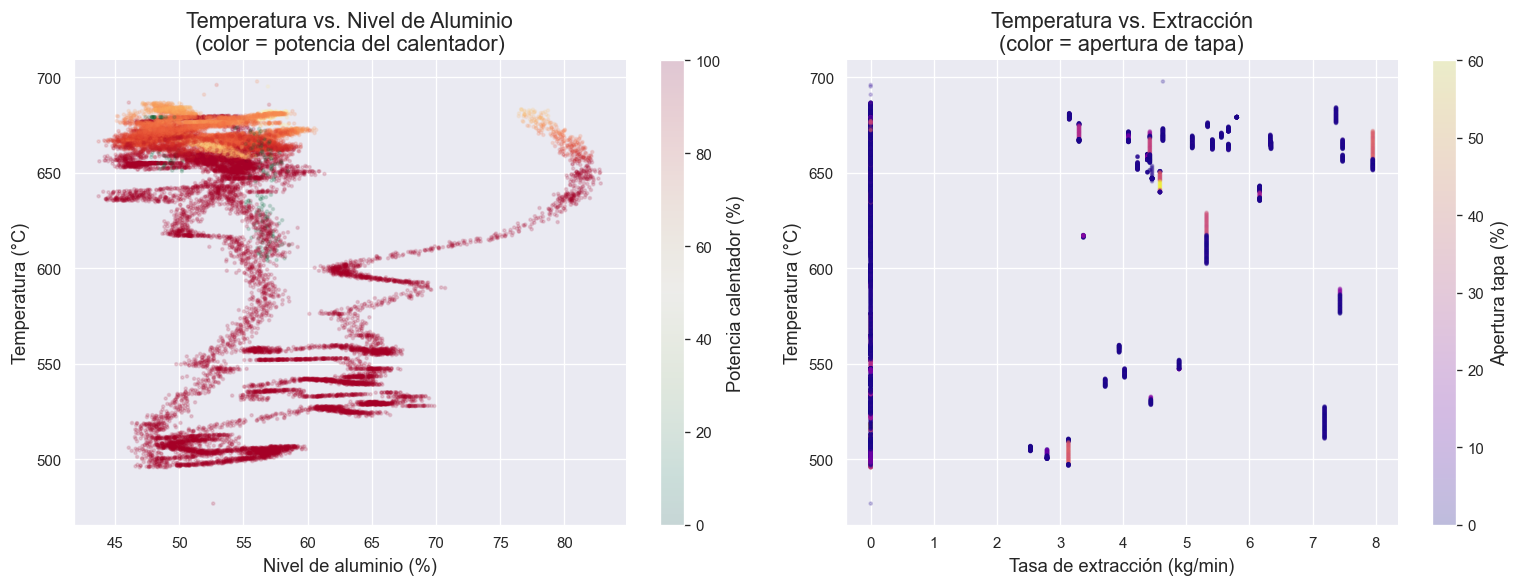

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# temperatura vs. nivel de aluminio
sc1 = axes[0].scatter(
    df_clean['aluminum_level_pct'],
    df_clean['sensor_temp_main'],
    c=df_clean['heater_power_pct'], cmap='RdYlGn_r',
    alpha=0.15, s=3
)
plt.colorbar(sc1, ax=axes[0], label='Potencia calentador (%)')
axes[0].set_xlabel('Nivel de aluminio (%)')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Temperatura vs. Nivel de Aluminio\n(color = potencia del calentador)')

# Temperatura vs. tasa de extracción
sc2 = axes[1].scatter(
    df_clean['production_draw_rate'],
    df_clean['sensor_temp_main'],
    c=df_clean['lid_opening_pct'], cmap='plasma',
    alpha=0.2, s=3
)
plt.colorbar(sc2, ax=axes[1], label='Apertura tapa (%)')
axes[1].set_xlabel('Tasa de extracción (kg/min)')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_title('Temperatura vs. Extracción\n(color = apertura de tapa)')

plt.tight_layout()
plt.savefig('fig_regimenes.png', bbox_inches='tight')
plt.show()
